<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_8960\1457651463.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


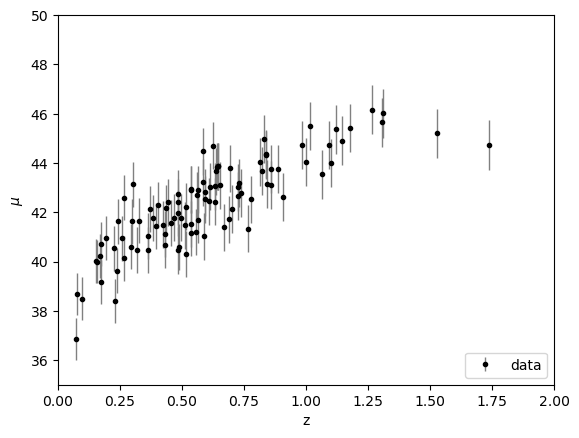

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


Linear fit:  slope = 4.764,  intercept = 39.484


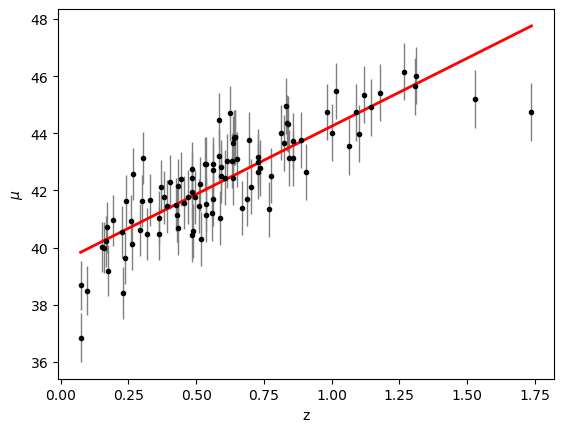

In [2]:
#start with linear regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

x = z_sample[:, np.newaxis]
y = mu_sample

model = LinearRegression()
weights = 1/dmu**2
model.fit(x, y, sample_weight=weights)

theta0 = model.intercept_
theta1 = model.coef_[0]
print(f'Linear fit:  slope = {theta1:.3f},  intercept = {theta0:.3f}')

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = theta1 * x_fit + theta0

plt.figure()
plt.errorbar(x, y, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x_fit, y_fit, 'r-', lw=2, label=f'Linear fit (d=1)')
plt.xlabel(r'z')
plt.ylabel(r'$\mu$')
plt.show()



[42.38034994]
[39.56505555  4.64711848]
[38.44821027  8.49035585 -2.57760572]
[38.49130243  8.23905057 -2.20391808 -0.15168104]
[ 37.0543994   20.74217865 -32.83020744  27.30599762  -7.98337391]
[ 36.18760445  31.00142053 -69.82397489  82.84185044 -44.24104125
   8.47059008]
[  35.52810145   41.0777603  -119.2923833   190.65950213 -159.23341791
   67.07109508  -11.37900289]
[   33.0388866     88.36455436  -419.10465978  1070.05460078
 -1505.50746677  1174.27289713  -473.67088511    76.75032208]
[  33.50565858   77.89342065 -337.63347914  765.4161251  -882.60407239
  442.01979981   18.73687926  -98.85713123   25.70456796]
[   35.26610351    32.52717373    84.29772055 -1185.19631674
  4221.8203542  -7581.90261829  7725.37966027 -4516.73127761
  1411.3078108   -182.6279746 ]


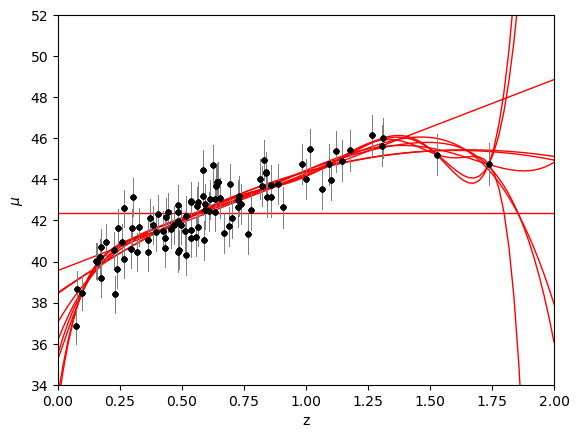

In [9]:
#now lets do the polynomial regression 

from astroML.linear_model import PolynomialRegression

z_test = np.linspace(0, 2, 100)

number_of_degrees = 10 

for i in range(number_of_degrees):
    degree = i
    model = PolynomialRegression(degree) # fit 3rd degree polynomial
    model.fit(z_sample[:, np.newaxis], mu_sample)

    y_pred = model.predict(z_test[:, np.newaxis])
    n_constraints = degree + 1

    print(model.coef_)

    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=0.7, label='data')
    plt.plot(z_test, y_pred, 'r-', lw=1, label=f'Polynomial fit (d={degree})')
    plt.xlabel(r'z')
    plt.ylabel(r'$\mu$')
    plt.ylim(34, 52)
    plt.xlim(0, 2)

plt.show()



In [14]:
#now lets split the into training and validation sets 

from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_val, y_train, y_val, dy_train, dy_val = train_test_split(x, y, dmu, test_size=0.3, random_state=42)

Grado n= 1 | Train Error: 1.049 | Validation Error: 0.824
Grado n= 2 | Train Error: 0.939 | Validation Error: 0.835
Grado n= 3 | Train Error: 0.938 | Validation Error: 0.835
Grado n= 4 | Train Error: 0.902 | Validation Error: 0.810
Grado n= 5 | Train Error: 0.892 | Validation Error: 0.814
Grado n= 6 | Train Error: 0.891 | Validation Error: 0.811
Grado n= 7 | Train Error: 0.870 | Validation Error: 0.816
Grado n= 8 | Train Error: 0.870 | Validation Error: 0.821
Grado n= 9 | Train Error: 0.870 | Validation Error: 0.822
Grado n=10 | Train Error: 0.867 | Validation Error: 0.846
Grado n=11 | Train Error: 0.862 | Validation Error: 0.851
Grado n=12 | Train Error: 0.856 | Validation Error: 0.819
Grado n=13 | Train Error: 0.853 | Validation Error: 0.825
Grado n=14 | Train Error: 0.841 | Validation Error: 0.812


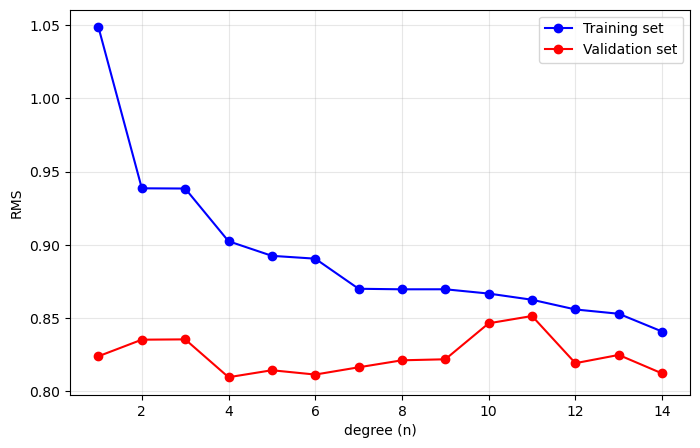

Best degree is n = 4 with a validation error of 0.8096


In [17]:
#help function

def geterror(X, y, model):
    pred = model.predict(X)
    return np.sqrt(np.mean((y - pred)**2))
def fitanderror(model):
    model.fit(X_train, y_train, dy_train)
    error_train = geterror(X_train, y_train, model)
    error_val   = geterror(X_val, y_val, model)
    return error_train, error_val


nrange = np.arange(1, 15)
etrain = []
etest = []
for n in nrange:
    model = PolynomialRegression(n)
    
    err_t, err_v = fitanderror(model)
    
    etrain.append(err_t)
    etest.append(err_v)
    print(f"Grado n={n:2d} | Train Error: {err_t:.3f} | Validation Error: {err_v:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(nrange, etrain, 'b-o', label='Training set')
plt.plot(nrange, etest, 'r-o', label='Validation set')
plt.xlabel('degree (n)')
plt.ylabel('RMS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
best_n = nrange[np.argmin(etest)]
print(f"Best degree is n = {best_n} with a validation error of {min(etest):.4f}")